# Keşifsel Veri Analizi (EDA)

**Proje:** ABD Trafik Kazalarında Hava Durumu, Yol Tipi ve Saat Bilgisine
Göre Kaza Şiddetinin Tahmini

Bu notebook, hazırlanmış veri seti üzerinde keşifsel veri analizi yapar:
betimsel istatistikler, değişken dağılımları, değişkenler arası ilişkiler
ve aykırı değer tespiti.

**Girdi:** `temiz_veri.parquet`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

df = pd.read_parquet("../data/processed/temiz_veri.parquet")

print("Boyut:", df.shape)
print()
print(df.head(3).to_string())

Boyut: (1420236, 47)

         ID  Severity          Start_Time  Start_Lat  Start_Lng                           Street   City        County State     Zipcode    Timezone  Temperature(F)  Humidity(%)  Pressure(in)  Visibility(mi) Wind_Direction  Wind_Speed(mph)  Precipitation(in) Weather_Condition  Amenity   Bump  Crossing  Give_Way  Junction  No_Exit  Railway  Roundabout  Station   Stop  Traffic_Calming  Traffic_Signal Sunrise_Sunset Civil_Twilight Nautical_Twilight Astronomical_Twilight    county_key  nufus_2022  nufus_yogunlugu  kentsel_kirsal  saat  gun  ay   yil  hafta_sonu  yogun_saat    mevsim   yol_tipi
0  A-116062         3 2016-11-30 15:36:03  27.981367 -82.326561  E Dr Martin Luther King Jr Blvd  Tampa  Hillsborough    FL       33610  US/Eastern            80.6         70.0         29.94            10.0            SSW              5.8                0.0          Overcast    False  False     False     False     False    False    False       False    False  False            Fal

## 1. Veriye ilk bakış

Veri setinin boyutu, sütun yapısı ve veri tipleri incelenmiştir.

In [3]:
print("Satır:", f"{df.shape[0]:,}")
print("Sütun:", df.shape[1])
print("Bellek:", f"{df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print()

print("Veri tipleri:")
print(df.dtypes.value_counts().to_string())
print()

print("Hedef değişken dağılımı (Severity):")
sev = df["Severity"].value_counts().sort_index()
sev_yuzde = (df["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)
print(pd.DataFrame({"adet": sev, "yuzde": sev_yuzde}).to_string())
print()

print("Eyalet dağılımı:")
print(df["State"].value_counts().to_string())
print()

print("Tarih aralığı:", df["Start_Time"].min(), "→", df["Start_Time"].max())

Satır: 1,420,236
Sütun: 47
Bellek: 493 MB

Veri tipleri:
str               16
bool              14
float64           11
int32              4
int64              1
datetime64[ns]     1

Hedef değişken dağılımı (Severity):
             adet  yuzde
Severity                
1            8819   0.62
2         1182645  83.27
3          204011  14.36
4           24761   1.74

Eyalet dağılımı:
State
FL    880192
NY    347960
MN    192084

Tarih aralığı: 2016-03-23 02:35:03 → 2023-03-31 23:09:00


## 2. Betimsel istatistikler

Sayısal değişkenlerin merkezi eğilim ve yayılım ölçüleri incelenmiştir.

In [4]:
SAYISAL = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
           "Wind_Speed(mph)", "Precipitation(in)", "nufus_yogunlugu", "saat"]

print(df[SAYISAL].describe().T.round(2).to_string())

                       count     mean       std    min     25%      50%      75%       max
Temperature(F)     1420236.0    65.30     20.86 -77.80   55.40    72.00    80.00    174.00
Humidity(%)        1420236.0    70.04     18.23   1.00   57.00    71.00    85.00    100.00
Pressure(in)       1420236.0    29.85      0.41   0.00   29.82    29.98    30.08     58.63
Visibility(mi)     1420236.0     9.21      2.29   0.00   10.00    10.00    10.00    105.00
Wind_Speed(mph)    1420236.0     8.71      5.23   0.00    5.80     8.00    12.00    984.00
Precipitation(in)  1420236.0     0.01      0.18   0.00    0.00     0.00     0.00     10.16
nufus_yogunlugu    1420097.0  4136.92  10820.98   2.97  622.64  1428.15  1634.58  70487.38
saat               1420236.0    12.37      5.37   0.00    8.00    13.00    17.00     23.00


## 3. Aykırı değer analizi

Betimsel istatistiklerde fiziksel olarak imkânsız değerler tespit edilmiştir
(984 mph rüzgâr hızı, 174°F sıcaklık, 105 mil görüş mesafesi, 0 inHg basınç).
Aykırı değerler önce IQR yöntemiyle ölçülmüş, ardından fiziksel sınırlara
göre düzeltilmiştir.

In [5]:
def iqr_aykiri(seri):
    Q1 = seri.quantile(0.25)
    Q3 = seri.quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    aykiri = ((seri < alt) | (seri > ust)).sum()
    return pd.Series({
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "alt_sinir": round(alt, 2),
        "ust_sinir": round(ust, 2),
        "aykiri_sayi": aykiri,
        "aykiri_yuzde": round(aykiri / len(seri) * 100, 2)
    })

SAYISAL = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
           "Wind_Speed(mph)", "Precipitation(in)", "nufus_yogunlugu"]

sonuc = pd.DataFrame({s: iqr_aykiri(df[s]) for s in SAYISAL}).T
print(sonuc.to_string())

                       Q1       Q3  alt_sinir  ust_sinir  aykiri_sayi  aykiri_yuzde
Temperature(F)      55.40    80.00      18.50     116.90      52243.0          3.68
Humidity(%)         57.00    85.00      15.00     127.00        569.0          0.04
Pressure(in)        29.82    30.08      29.43      30.47     200853.0         14.14
Visibility(mi)      10.00    10.00      10.00      10.00     220215.0         15.51
Wind_Speed(mph)      5.80    12.00      -3.50      21.30      23382.0          1.65
Precipitation(in)    0.00     0.00       0.00       0.00     105105.0          7.40
nufus_yogunlugu    622.64  1634.58    -895.27    3152.49     209313.0         14.74


### 3.2 Fiziksel sınırlara göre düzeltme

IQR yöntemi çarpık ve doyuma ulaşmış dağılımlarda yanıltıcı sonuç verdiği
için, aykırı değer temizliğinde meteorolojik gerçekliğe dayalı sınırlar
kullanılmıştır. Sınır dışı değerler silinmemiş, ilgili sınıra sabitlenmiştir
(clipping); böylece satır kaybı yaşanmamıştır.

In [6]:
SINIRLAR = {
    "Temperature(F)":    (-40, 130),
    "Humidity(%)":       (0, 100),
    "Pressure(in)":      (25, 32),
    "Visibility(mi)":    (0, 20),
    "Wind_Speed(mph)":   (0, 100),
    "Precipitation(in)": (0, 10),
}

print("SINIR DIŞI DEĞERLER")
for sutun, (alt, ust) in SINIRLAR.items():
    disarda = ((df[sutun] < alt) | (df[sutun] > ust)).sum()
    print(f"{sutun:<20} {disarda:>7,}  ({disarda/len(df)*100:.3f}%)")

# Sınırlara sabitle
for sutun, (alt, ust) in SINIRLAR.items():
    df[sutun] = df[sutun].clip(lower=alt, upper=ust)

print()
print("DÜZELTME SONRASI (min / max)")
print(df[list(SINIRLAR.keys())].describe().T[["min", "max"]].to_string())

SINIR DIŞI DEĞERLER
Temperature(F)            22  (0.002%)
Humidity(%)                0  (0.000%)
Pressure(in)              26  (0.002%)
Visibility(mi)             9  (0.001%)
Wind_Speed(mph)           27  (0.002%)
Precipitation(in)         44  (0.003%)

DÜZELTME SONRASI (min / max)
                    min    max
Temperature(F)    -40.0  130.0
Humidity(%)         1.0  100.0
Pressure(in)       25.0   32.0
Visibility(mi)      0.0   20.0
Wind_Speed(mph)     0.0  100.0
Precipitation(in)   0.0   10.0


## 4. Görselleştirme

### 4.1 Hedef değişken dağılımı

Kaza şiddeti sınıflarının dağılımı incelenmiştir. Sınıflar arasındaki
dengesizlik, model değerlendirme metriğinin seçimini doğrudan etkilemektedir.

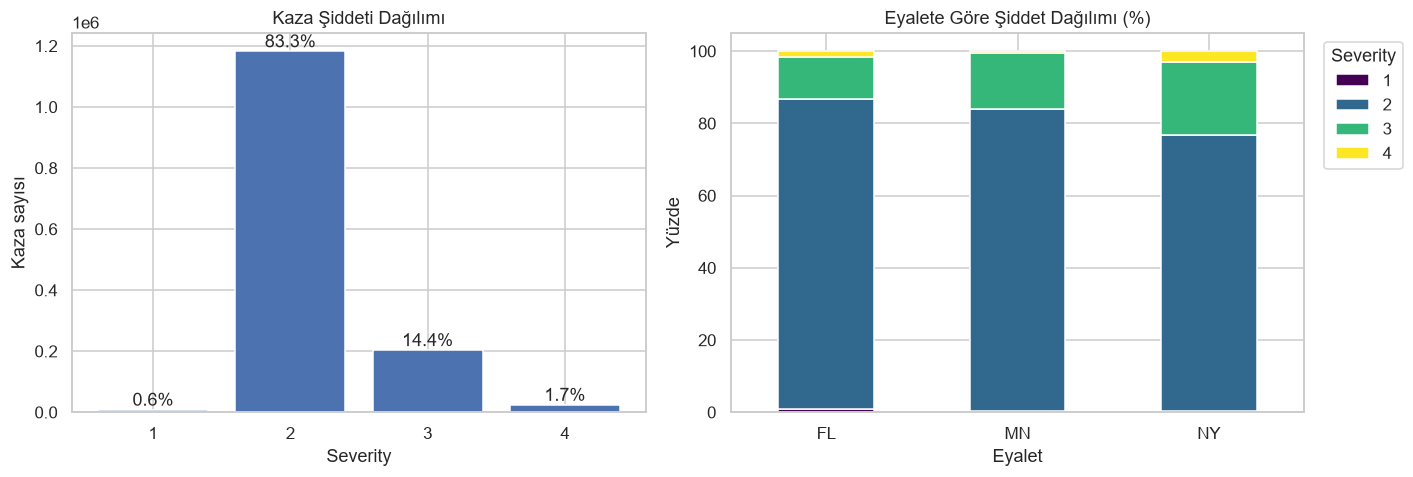

Severity     1      2      3     4
State                             
FL        0.80  85.88  11.82  1.49
MN        0.25  83.74  15.56  0.45
NY        0.36  76.42  20.14  3.09


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sol: genel dağılım
sev = df["Severity"].value_counts().sort_index()
axes[0].bar(sev.index.astype(str), sev.values, color="#4C72B0")
axes[0].set_title("Kaza Şiddeti Dağılımı")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Kaza sayısı")
for i, v in enumerate(sev.values):
    axes[0].text(i, v, f"{v/len(df)*100:.1f}%", ha="center", va="bottom")

# Sağ: eyalet kırılımı (oran)
oran = pd.crosstab(df["State"], df["Severity"], normalize="index") * 100
oran.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Eyalete Göre Şiddet Dağılımı (%)")
axes[1].set_xlabel("Eyalet")
axes[1].set_ylabel("Yüzde")
axes[1].legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(oran.round(2).to_string())

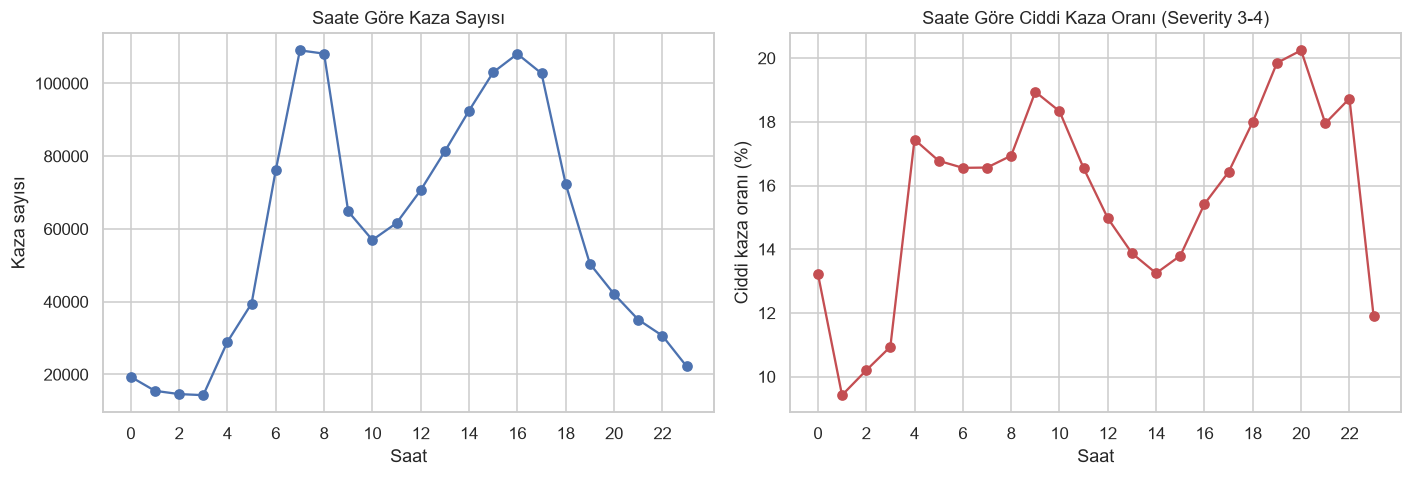

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sol: saatlik kaza sayısı
saatlik = df["saat"].value_counts().sort_index()
axes[0].plot(saatlik.index, saatlik.values, marker="o", color="#4C72B0")
axes[0].set_title("Saate Göre Kaza Sayısı")
axes[0].set_xlabel("Saat")
axes[0].set_ylabel("Kaza sayısı")
axes[0].set_xticks(range(0, 24, 2))

# Sağ: saate göre ciddi kaza oranı (3+4)
df["ciddi"] = df["Severity"].isin([3, 4])
oran_saat = df.groupby("saat")["ciddi"].mean() * 100
axes[1].plot(oran_saat.index, oran_saat.values, marker="o", color="#C44E52")
axes[1].set_title("Saate Göre Ciddi Kaza Oranı (Severity 3-4)")
axes[1].set_xlabel("Saat")
axes[1].set_ylabel("Ciddi kaza oranı (%)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

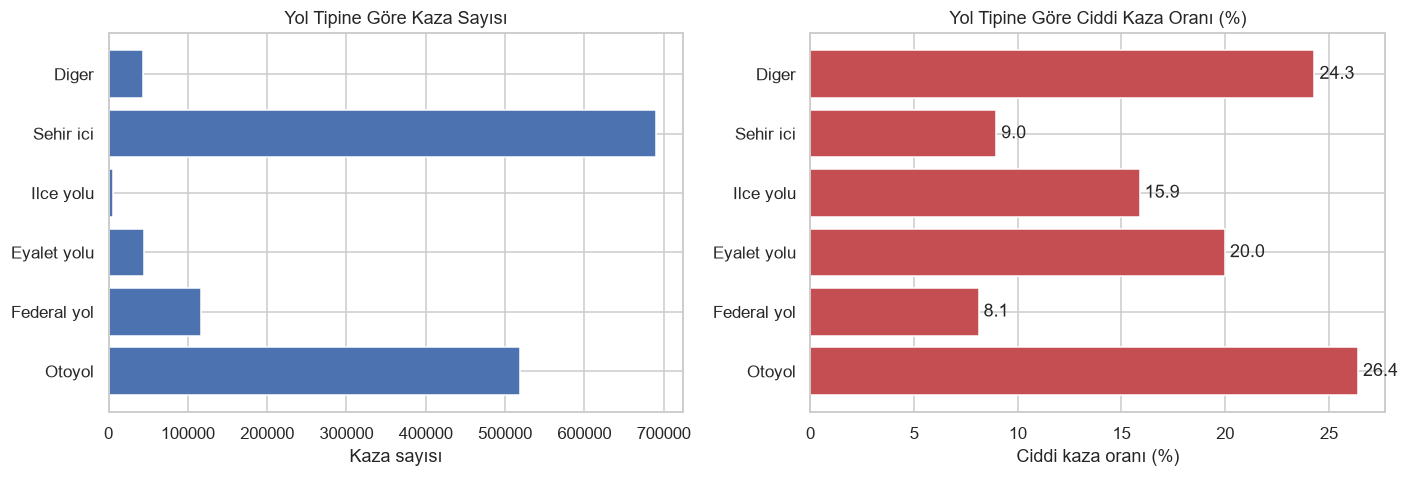

              count  ciddi_yuzde
yol_tipi                        
Otoyol       518920        26.41
Federal yol  116779         8.11
Eyalet yolu   44900        19.99
Ilce yolu      6015        15.88
Sehir ici    690357         8.96
Diger         43265        24.31


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sira = ["Otoyol", "Federal yol", "Eyalet yolu", "Ilce yolu", "Sehir ici", "Diger"]

# Sol: kaza sayısı
sayi = df["yol_tipi"].value_counts().reindex(sira)
axes[0].barh(sayi.index, sayi.values, color="#4C72B0")
axes[0].set_title("Yol Tipine Göre Kaza Sayısı")
axes[0].set_xlabel("Kaza sayısı")

# Sağ: ciddi kaza oranı
oran = (df.groupby("yol_tipi")["ciddi"].mean() * 100).reindex(sira)
axes[1].barh(oran.index, oran.values, color="#C44E52")
axes[1].set_title("Yol Tipine Göre Ciddi Kaza Oranı (%)")
axes[1].set_xlabel("Ciddi kaza oranı (%)")
for i, v in enumerate(oran.values):
    axes[1].text(v, i, f" {v:.1f}", va="center")

plt.tight_layout()
plt.show()

print((df.groupby("yol_tipi")["ciddi"].agg(["count", "mean"])
       .assign(ciddi_yuzde=lambda x: (x["mean"]*100).round(2))
       .drop(columns="mean").reindex(sira).to_string()))

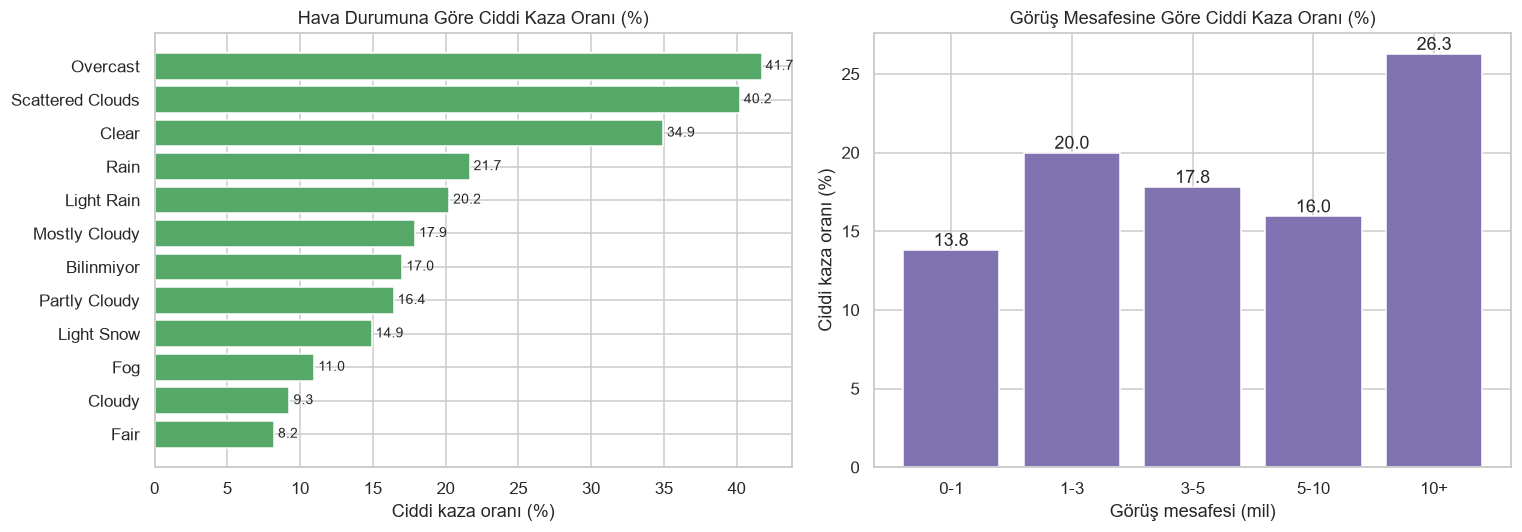

Weather_Condition
Fair                456014
Mostly Cloudy       242994
Partly Cloudy       169604
Cloudy              140973
Clear                95246
Light Rain           61443
Overcast             46010
Scattered Clouds     42484
Light Snow           36556
Bilinmiyor           15700
Fog                  14235
Rain                 11939


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: en sık 12 hava durumu
top12 = df["Weather_Condition"].value_counts().head(12).index
alt = df[df["Weather_Condition"].isin(top12)]
oran_hava = (alt.groupby("Weather_Condition")["ciddi"].mean() * 100).sort_values()

axes[0].barh(oran_hava.index, oran_hava.values, color="#55A868")
axes[0].set_title("Hava Durumuna Göre Ciddi Kaza Oranı (%)")
axes[0].set_xlabel("Ciddi kaza oranı (%)")
for i, v in enumerate(oran_hava.values):
    axes[0].text(v, i, f" {v:.1f}", va="center", fontsize=9)

# Sağ: görüş mesafesi
df["gorus_grup"] = pd.cut(df["Visibility(mi)"],
                          bins=[-0.1, 1, 3, 5, 10, 20],
                          labels=["0-1", "1-3", "3-5", "5-10", "10+"])
oran_gorus = df.groupby("gorus_grup", observed=True)["ciddi"].mean() * 100

axes[1].bar(oran_gorus.index.astype(str), oran_gorus.values, color="#8172B2")
axes[1].set_title("Görüş Mesafesine Göre Ciddi Kaza Oranı (%)")
axes[1].set_xlabel("Görüş mesafesi (mil)")
axes[1].set_ylabel("Ciddi kaza oranı (%)")
for i, v in enumerate(oran_gorus.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(df["Weather_Condition"].value_counts().head(12).to_string())

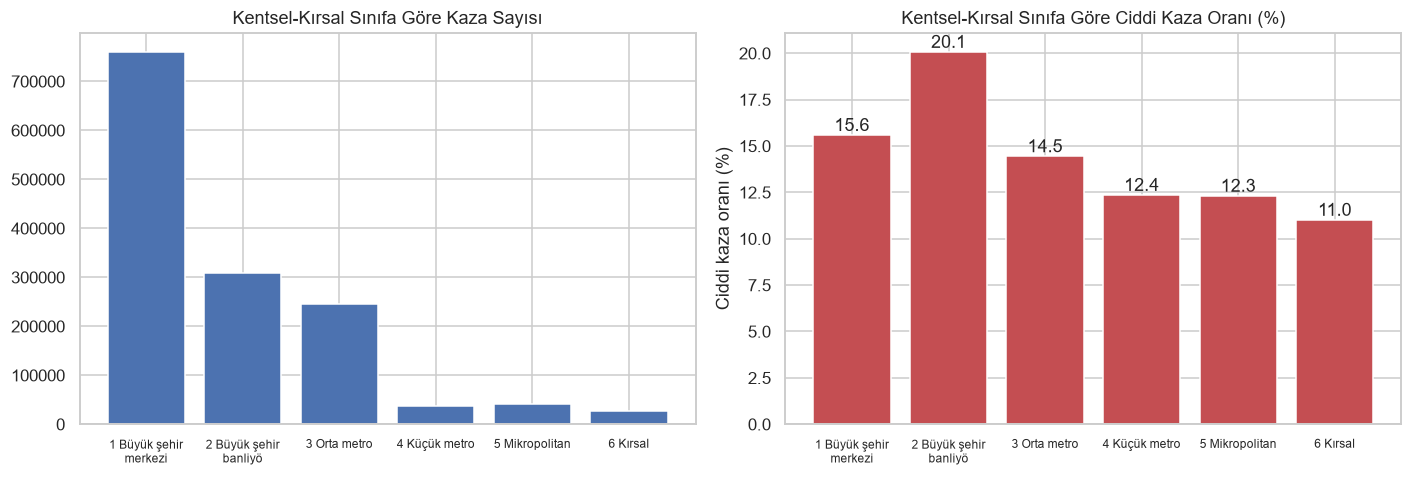

                 count  ciddi_yuzde
kentsel_kirsal                     
1.0             760535        15.60
2.0             308309        20.08
3.0             245326        14.46
4.0              37335        12.37
5.0              42321        12.32
6.0              26271        11.03


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

etiket = {1: "1 Büyük şehir\nmerkezi", 2: "2 Büyük şehir\nbanliyö",
          3: "3 Orta metro", 4: "4 Küçük metro",
          5: "5 Mikropolitan", 6: "6 Kırsal"}

# Sol: kaza sayısı
sayi = df["kentsel_kirsal"].value_counts().sort_index()
axes[0].bar([etiket.get(i, str(i)) for i in sayi.index], sayi.values, color="#4C72B0")
axes[0].set_title("Kentsel-Kırsal Sınıfa Göre Kaza Sayısı")
axes[0].tick_params(axis="x", labelsize=8)

# Sağ: ciddi kaza oranı
oran = (df.groupby("kentsel_kirsal")["ciddi"].mean() * 100).sort_index()
axes[1].bar([etiket.get(i, str(i)) for i in oran.index], oran.values, color="#C44E52")
axes[1].set_title("Kentsel-Kırsal Sınıfa Göre Ciddi Kaza Oranı (%)")
axes[1].set_ylabel("Ciddi kaza oranı (%)")
axes[1].tick_params(axis="x", labelsize=8)
for i, v in enumerate(oran.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(df.groupby("kentsel_kirsal")["ciddi"].agg(["count", "mean"])
      .assign(ciddi_yuzde=lambda x: (x["mean"]*100).round(2))
      .drop(columns="mean").to_string())

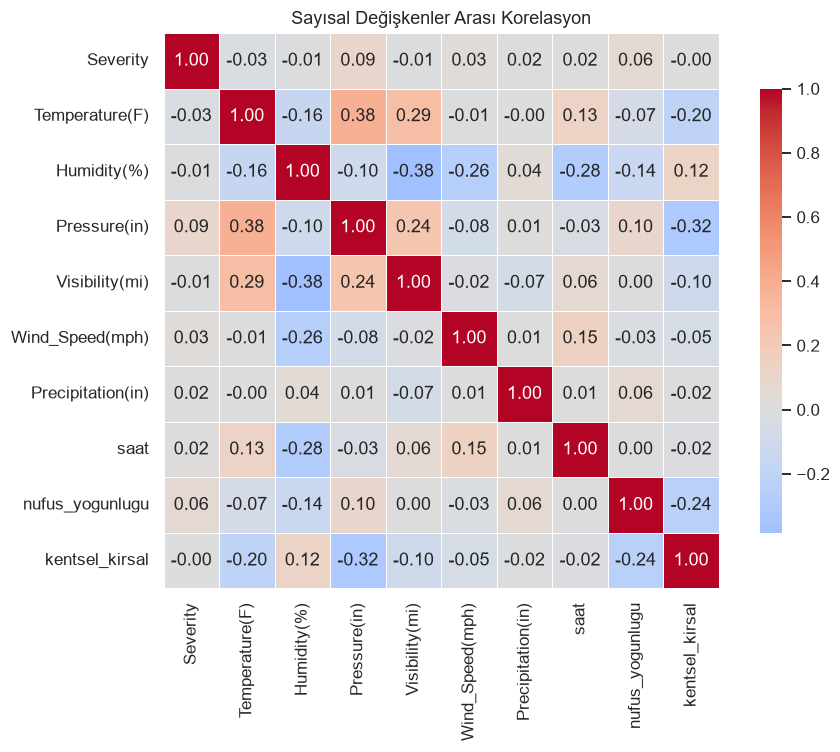

Severity ile korelasyonlar:
Pressure(in)         0.088
nufus_yogunlugu      0.061
Wind_Speed(mph)      0.027
Precipitation(in)    0.015
saat                 0.015
kentsel_kirsal      -0.004
Humidity(%)         -0.008
Visibility(mi)      -0.008
Temperature(F)      -0.029


In [17]:
KORELASYON = ["Severity", "Temperature(F)", "Humidity(%)", "Pressure(in)",
              "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)",
              "saat", "nufus_yogunlugu", "kentsel_kirsal"]

korr = df[KORELASYON].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(korr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.tight_layout()
plt.show()

print("Severity ile korelasyonlar:")
print(korr["Severity"].drop("Severity").sort_values(ascending=False).round(3).to_string())